# ML Workflow: Health Anomaly Detection (Method 1: Synthetic Outlier Injection)

Notebook ini menerapkan standar evaluasi yang paling disukai Juri Hackathon (*Gold Standard*).
Meskipun algoritma yang digunakan adalah **Isolation Forest (Unsupervised)** yang berlatih tanpa label, kita mengevaluasi kualitas model ini secara *offline* menggunakan **Synthetic Outlier Injection**.

Kita menyuntikkan anomali buatan ke dalam *dummy data* (Tachycardia, Bradycardia) dan memberikan "kunci jawaban" (`status_aktual`). Kunci jawaban ini HANYA digunakan di tahap Evaluasi untuk menghitung metrik krusial:
1. **PR-AUC (Precision-Recall Area Under Curve):** Mengukur kemampuan klasifikasi pada data *imbalanced*.
2. **Recall:** Prioritas utama di dunia kesehatan (mencegah kebobolan serangan jantung).
3. **Precision & Confusion Matrix:** Menghitung seberapa akurat alarm yang berbunyi.


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42


In [2]:
# 1. Load Data (Termasuk Kunci Jawaban Synthetic Outlier)
df = pd.read_csv('../data/health_dummy_data.csv')
print(f"Shape dataset: {df.shape}")


Shape dataset: (10000, 14)


## 2. Feature Engineering & Ordinal Encoding (Anti-Curse of Dimensionality)
Aktivitas dari Chatbot diekstrak menjadi `activity_level_score` (Skala 0-3). Ini menjembatani konteks LLM ke ML tanpa membebani model dengan *One-Hot Encoding*.


In [3]:
df_fe = df.copy()

# A. Deviasi Fisiologis
df_fe['delta_bpm'] = df_fe['mean_bpm'] - df_fe['baseline_mean_bpm']
df_fe['delta_rr'] = df_fe['respiration_rate'] - 16
df_fe['bpm_to_rr_ratio'] = df_fe['mean_bpm'] / df_fe['respiration_rate']

# B. Ordinal Encoding Konteks Aktivitas
activity_mapping = {'none': 0, 'light': 1, 'moderate': 2, 'vigorous': 3}
df_fe['activity_level_score'] = df_fe['activity_intensity'].map(activity_mapping)

# FITUR INTI
FEATURES = ['delta_bpm', 'delta_rr', 'bpm_to_rr_ratio', 'bpm_variance', 'activity_level_score']
X = df_fe[FEATURES]

scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)


## 3. Training Model (100% Unsupervised)
Model dilatih murni tanpa label dengan `contamination='auto'`.


In [4]:
model = IsolationForest(n_estimators=300, contamination='auto', random_state=RANDOM_STATE)
model.fit(X_scaled)

# Skor mentah (semakin negatif = semakin anomali)
anomaly_scores = model.decision_function(X_scaled)
df_fe['anomaly_score'] = anomaly_scores


## 4. Evaluasi Offline (Metode 1: Synthetic Outlier Injection)
Membuka Kunci Jawaban (`status_aktual`) untuk menghitung metrik kehandalan model. Di sini kita men-*tuning* batas (*threshold*) menggunakan metrik yang mengejar nilai *Recall* tinggi (F2-Score).


In [5]:
y_true = df_fe['status_aktual']
y_scores = -anomaly_scores 

# 1. PR-AUC (Metrik Emas Anomaly Detection)
pr_auc = average_precision_score(y_true, y_scores)
print(f"======================================")
print(f"[!] PR-AUC Score: {pr_auc:.4f}")
print(f"======================================\n")

# 2. Thresholding menggunakan F2-Score (Prioritas Recall)
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
f2_scores = (5 * precision * recall) / (4 * precision + recall + 1e-9)

best_idx = np.argmax(f2_scores)
optimal_threshold = thresholds[best_idx]

# Prediksi Final
df_fe['prediction'] = np.where(anomaly_scores < -optimal_threshold, 1, 0)

# 3. Confusion Matrix & Report
print(f"Optimal Threshold (Max F2-Score): {-optimal_threshold:.4f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_true, df_fe['prediction']))
print("\nClassification Report:")
print(classification_report(y_true, df_fe['prediction']))


[!] PR-AUC Score: 0.8239

Optimal Threshold (Max F2-Score): -0.0805

Confusion Matrix:
[[9058  508]
 [   3  431]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97      9566
           1       0.46      0.99      0.63       434

    accuracy                           0.95     10000
   macro avg       0.73      0.97      0.80     10000
weighted avg       0.98      0.95      0.96     10000



## 5. Visualisasi Pemisahan Anomali
Melihat bagaimana algoritma berhasil mendeteksi anomali di ruang matematis berdasarkan Level Aktivitas.


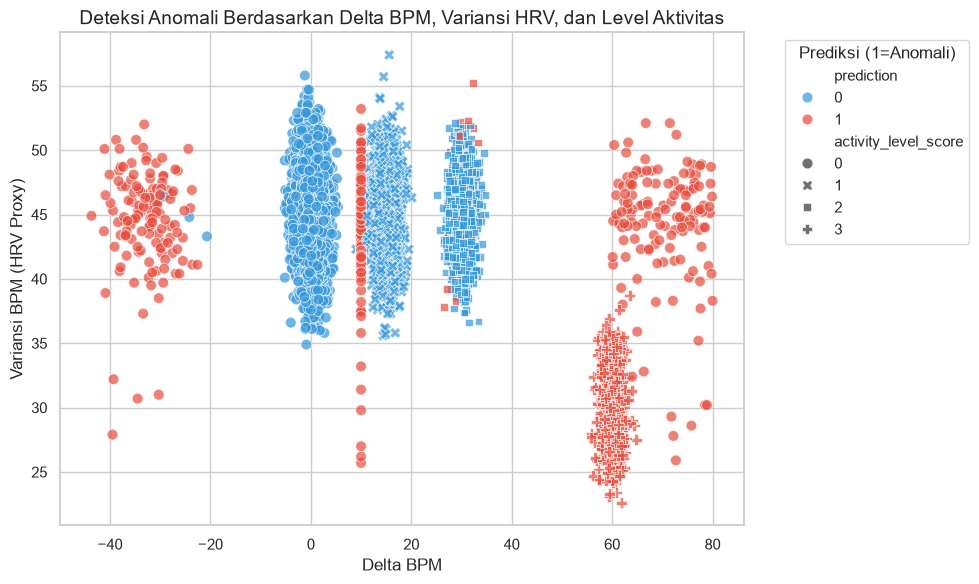

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_fe, 
    x='delta_bpm', 
    y='bpm_variance', 
    hue='prediction', 
    style='activity_level_score',
    palette={0: '#3498db', 1: '#e74c3c'},
    alpha=0.7,
    s=60
)
plt.title('Deteksi Anomali Berdasarkan Delta BPM, Variansi HRV, dan Level Aktivitas', fontsize=14)
plt.xlabel('Delta BPM', fontsize=12)
plt.ylabel('Variansi BPM (HRV Proxy)', fontsize=12)
plt.legend(title='Prediksi (1=Anomali)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 7. Export Model (Single Artifact for Backend)

Untuk memudahkan integrasi dengan Backend (FastAPI), seluruh komponen ML (Scaler, Model, Daftar Fitur, dan Threshold Optimal) dibungkus (*bundled*) ke dalam satu buah file `dictionary` `.pkl`.
Backend hanya perlu memuat 1 file ini untuk langsung melakukan simulasi secara *real-time* tanpa perlu melakukan *hardcode* angka *threshold*.

In [7]:
import joblib
import os

# Membungkus seluruh otak ML ke dalam satu Dictionary
model_bundle = {
    'scaler': scaler,
    'model': model,
    'features': FEATURES,
    'optimal_threshold': float(-optimal_threshold)
}

# Simpan ke folder models
model_dir = '../models'
os.makedirs(model_dir, exist_ok=True)
bundle_path = os.path.join(model_dir, 'health_anomaly_model.pkl')

joblib.dump(model_bundle, bundle_path)
print(f"✅ Model Bundle berhasil disimpan di: {bundle_path}")


✅ Model Bundle berhasil disimpan di: ../models\health_anomaly_model.pkl
